# Control Work 1


- Linear regression: Dependent variable: GDPperCapita
- Linear regression: Predictors: Income, Development, Region + not less than 5 continuous variables which have the highest correlation with GDPperCapita
- Cluster analysis: GDPperCapita + not less than 5 continuous variables which have the correlation with GDPperCapita less than 0,5



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
import warnings
warnings.filterwarnings("ignore")
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
original_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/index2022_data.csv', sep=';', on_bad_lines='skip')
df = original_df.copy()
df

,CountryID,CountryName,HighIncome,Income,Development,Region,WorldRank,RegionRank,2022Score,PropertyRights,...,GovernmentExpenditurofGDP,Population,GDP,GDP_GrowthRate,5Year_GDP_GrowthRate,GDPperCapita,Unemployment,Inflation,FDIInflow,PublicDebt
0,1,Afghanistan,0,low income,developing,Asia-Pacific,NaN,NaN,NaN,NaN,...,NaN,"38,9","$78,7","-5,0","1,0",$2 390,"11,7","5,6","13,0","7,8"
1,2,Albania,0,middle income,developing,Europe,50.0,30.0,"66,6","55,5",...,"30,5","2,8","$40,7","-3,5","2,0",$14 218,"11,7","1,6","1 107,0","76,0"
2,3,Algeria,0,middle income,developing,Middle East and North Africa,167.0,13.0,"45,8","27,9",...,"37,8","43,9","$491,5","-6,0","0,1",$11 112,"12,8","2,4","1 125,0","53,1"
3,4,Angola,0,middle income,developing,Sub-Saharan Africa,139.0,29.0,"52,6","39,8",...,"21,3","32,9","$215,1","-4,0","-1,9",$6 932,"7,7","22,3","-1 866,0","127,1"
4,5,Argentina,0,middle income,developing,Americas,144.0,27.0,"50,1","35,1",...,"39,6","45,4","$941,8","-10,0","-2,8",$20 751,"11,7","42,0","4 123,0","103,0"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,182,Zambia,0,middle income,developing,Sub-Saharan Africa,154.0,36.0,"48,7","38,3",...,"29,8","18,4","$63,1","-3,5","1,9",$3 342,"12,2","16,4","234,0","117,8"
180,183,Zimbabwe,0,middle income,developing,Sub-Saharan Africa,173.0,46.0,"33,1","20,8",...,"20,7","14,9","$39,8","-8,0","-1,3",$2 622,"5,7","557,2","194,0","88,9"
181,184,Somalia,0,low income,developing,Sub-Saharan Africa,NaN,NaN,NaN,NaN,...,NaN,"15,9","$13,9","-1,5","1,6958",$925,"13,1",NaN,"464,0",NaN
182,185,Kosovo,0,middle income,developing,Europe,86.0,40.0,"60,1","47,4",...,"30,7","1,8","$20,4","-6,0","2,2",$11 274,NaN,"0,2","304,2259986","24,4"


## Task 1
- Do the descriptive analysis of all the variables which will be used in cluster analysis. Make sure the selected variables could be used simultaneously in one cluster model.
- Select a suitable cluster algorithm. Explain your selection.
- Define the number of clusters. Explain your decision.
- Describe the clusters. Each cluster should have its profile: name and detailed description in textual form based on the calculated statistical characteristic. Explain your selection of names.

In [ ]:
# Fix data types
df = df.dropna()

df['GDPperCapita'] = df['GDPperCapita'].replace({'\$': ''}, regex=True).str.replace(' ', '').str.replace(',', '.').astype(float)
df['GDP'] = df['GDP'].replace({'\$': ''}, regex=True).str.replace(' ', '').str.replace(',', '.').astype(float)
df['2022Score'] = df['2022Score'].str.replace(' ', '').str.replace(',', '.').astype(float)
df['PropertyRights'] = df['PropertyRights'].str.replace(' ', '').str.replace(',', '.').astype(float)
df['Population'] = df['Population'].str.replace(' ', '').str.replace(',', '.').astype(float)
df['GDP_GrowthRate'] = df['GDP_GrowthRate'].str.replace(' ', '').str.replace(',', '.').astype(float)
df['5Year_GDP_GrowthRate'] = df['5Year_GDP_GrowthRate'].str.replace(' ', '').str.replace(',', '.').astype(float)
df['Unemployment'] = df['Unemployment'].str.replace(' ', '').str.replace(',', '.').astype(float)
df['Inflation'] = df['Inflation'].str.replace(' ', '').str.replace(',', '.').astype(float)
df['FDIInflow'] = df['FDIInflow'].str.replace(' ', '').str.replace(',', '.').astype(float)
df['PublicDebt'] = df['PublicDebt'].str.replace(' ', '').str.replace(',', '.').astype(float)

df

,CountryID,CountryName,HighIncome,Income,Development,Region,WorldRank,RegionRank,2022Score,PropertyRights,...,GovernmentExpenditurofGDP,Population,GDP,GDP_GrowthRate,5Year_GDP_GrowthRate,GDPperCapita,Unemployment,Inflation,FDIInflow,PublicDebt
1,2,Albania,0,middle income,developing,Europe,50.0,30.0,66.6,55.5,...,"30,5",2.8,40.7,-3.5,2.0,14218.0,11.7,1.6,1107.0,76.0
2,3,Algeria,0,middle income,developing,Middle East and North Africa,167.0,13.0,45.8,27.9,...,"37,8",43.9,491.5,-6.0,0.1,11112.0,12.8,2.4,1125.0,53.1
3,4,Angola,0,middle income,developing,Sub-Saharan Africa,139.0,29.0,52.6,39.8,...,"21,3",32.9,215.1,-4.0,-1.9,6932.0,7.7,22.3,-1866.0,127.1
4,5,Argentina,0,middle income,developing,Americas,144.0,27.0,50.1,35.1,...,"39,6",45.4,941.8,-10.0,-2.8,20751.0,11.7,42.0,4123.0,103.0
5,6,Armenia,0,middle income,developing,Europe,58.0,34.0,65.3,50.4,...,"26,5",3.0,39.4,-7.6,2.6,13261.0,20.2,1.2,117.0,62.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,179,Venezuela,0,middle income,developing,Americas,176.0,32.0,24.8,0.2,...,"26,9",28.4,144.7,-30.0,-23.5,5178.0,9.1,2355.1,959.0,304.1
177,180,Vietnam,0,middle income,developing,Asia-Pacific,84.0,18.0,60.6,49.6,...,"22,0",97.3,1058.7,2.9,6.1,10869.0,2.3,3.2,15800.0,46.6
179,182,Zambia,0,middle income,developing,Sub-Saharan Africa,154.0,36.0,48.7,38.3,...,"29,8",18.4,63.1,-3.5,1.9,3342.0,12.2,16.4,234.0,117.8
180,183,Zimbabwe,0,middle income,developing,Sub-Saharan Africa,173.0,46.0,33.1,20.8,...,"20,7",14.9,39.8,-8.0,-1.3,2622.0,5.7,557.2,194.0,88.9


In [ ]:
unique_income_values = df['Income'].unique()
unique_development_values = df['Development'].unique()
unique_income_values, unique_development_values

(array(['middle income', 'high income', 'low income'], dtype=object),
 array(['developing', 'developed'], dtype=object))

In [ ]:
income_mapping = {
    'low income': 1,
    'middle income': 2,
    'high income': 3
}

development_mapping = {
    'developed': 1,
    'developing': 0
}

df['Income'] = df['Income'].map(income_mapping)
df['Development'] = df['Development'].map(development_mapping)

print(df[['Income', 'Development']])

     Income  Development
1         2            0
2         2            0
3         2            0
4         2            0
5         2            0
..      ...          ...
176       2            0
177       2            0
179       2            0
180       2            0
183       3            0

[170 rows x 2 columns]


In [ ]:
# Correlation with GDPperCapita
correlations = df.corr(numeric_only=True)['GDPperCapita'].sort_values(ascending=False)

correlations

,GDPperCapita
GDPperCapita,1.000000
HighIncome,0.812269
Income,0.767090
PropertyRights,0.747350
2022Score,0.716145
Development,0.657428
FinancialFreedom,0.639829
InvestmentFreedom,0.545289
FDIInflow,0.238033
GDP,0.164234


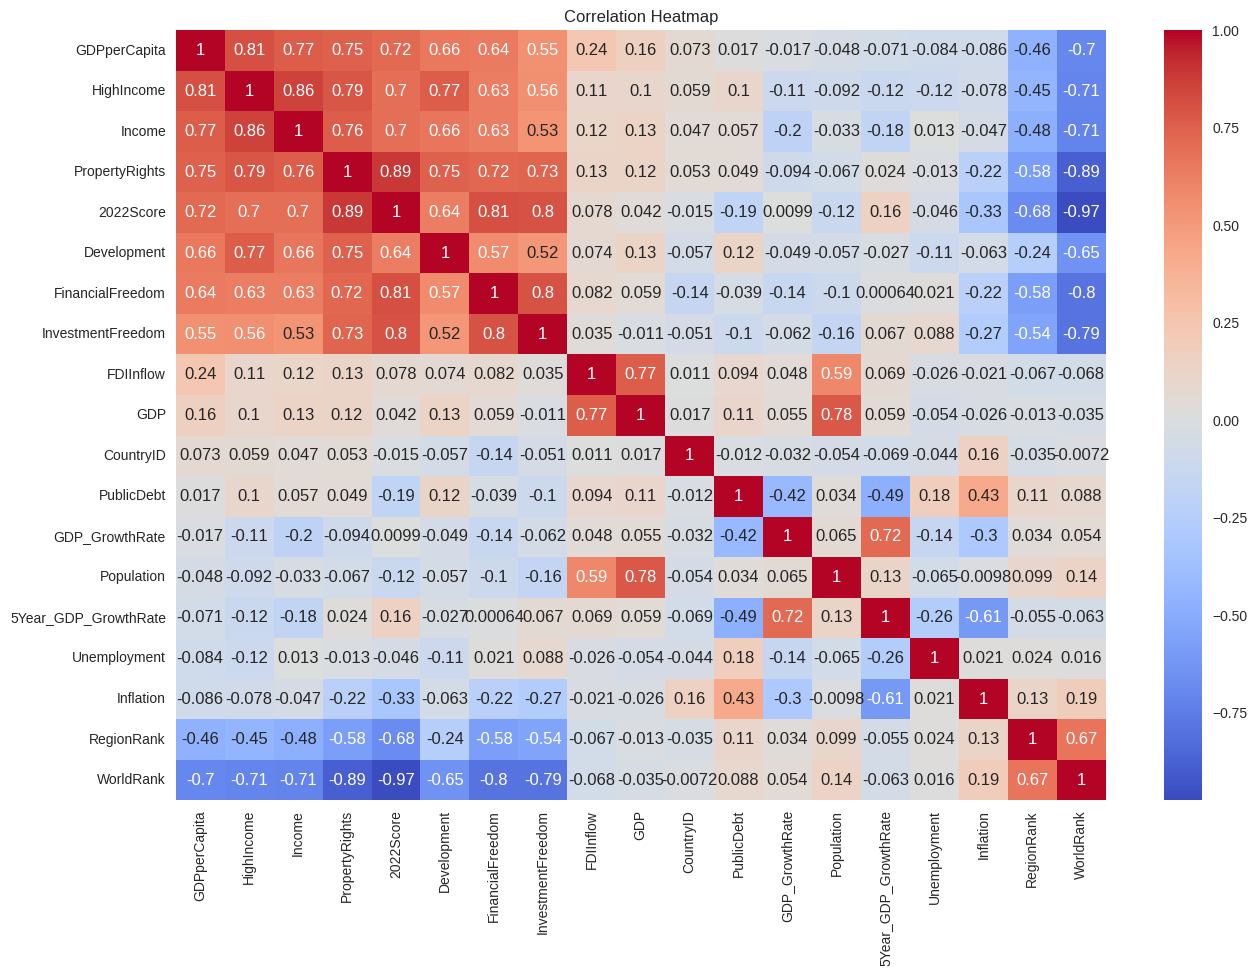

In [ ]:
plt.figure(figsize=(15, 10))
# Get the column names from the index of 'correlations'
columns_to_plot = correlations.index
sns.heatmap(df[columns_to_plot].corr(), annot=True, cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap')
plt.show()

We will take the least correlating categories but there are some with higher than 0.5. These are: PublicDebt, Population, GDP_GrowthRate, GDP, 5Year_GDP_GrowthRate

### Descriptive Analysis

In [ ]:
df[['GDPperCapita', 'PublicDebt', 'Population', 'GDP_GrowthRate', 'GDP', '5Year_GDP_GrowthRate']].describe()

,GDPperCapita,PublicDebt,Population,GDP_GrowthRate,GDP,5Year_GDP_GrowthRate
count,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000
mean,20955.252941,70.438235,44.320000,-4.421176,767.043529,1.505294
std,21496.450462,44.746926,155.472938,6.760626,2622.009602,3.207374
min,760.000000,2.900000,0.100000,-32.200000,0.600000,-23.500000
25%,5157.000000,43.050000,2.825000,-7.000000,31.075000,0.100000
50%,13091.500000,60.700000,9.800000,-3.850000,103.850000,1.500000
75%,31263.250000,85.000000,32.125000,-1.000000,486.475000,3.000000
max,118002.000000,304.100000,1402.100000,43.400000,24142.800000,12.100000


In [ ]:
columns_to_check = ['GDPperCapita', 'PublicDebt', 'Population', 'GDP_GrowthRate', 'GDP', '5Year_GDP_GrowthRate']

for column in columns_to_check:
    unique_values = df[column].nunique()
    print(f"{column} has {unique_values} unique values")

GDPperCapita has 170 unique values
PublicDebt has 155 unique values
Population has 133 unique values
GDP_GrowthRate has 109 unique values
GDP has 164 unique values
5Year_GDP_GrowthRate has 81 unique values


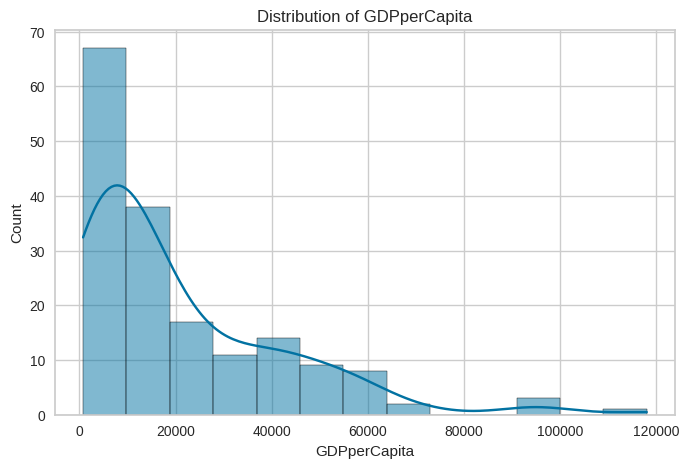

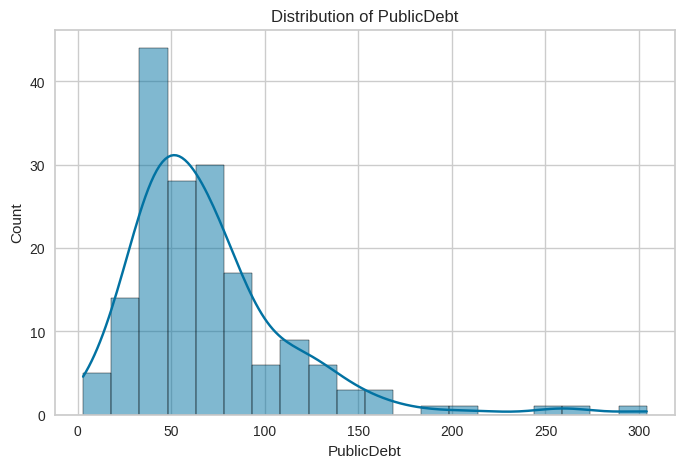

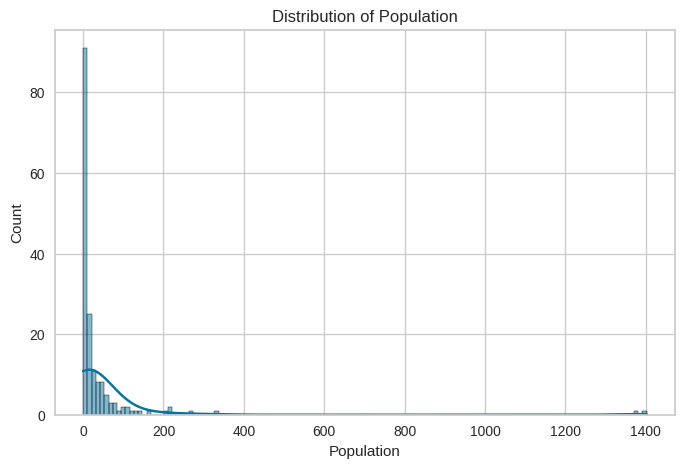

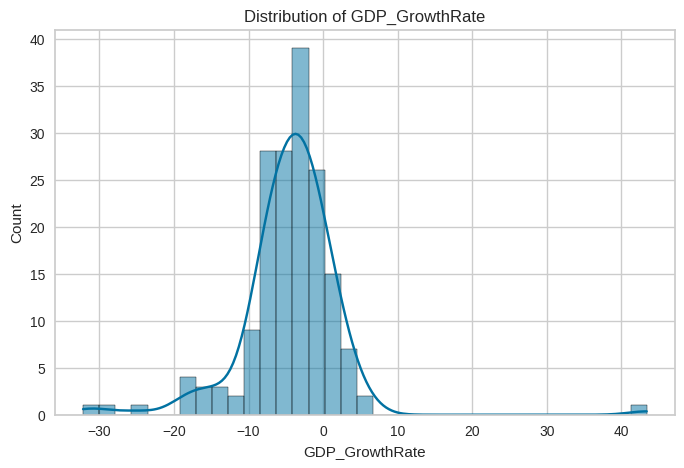

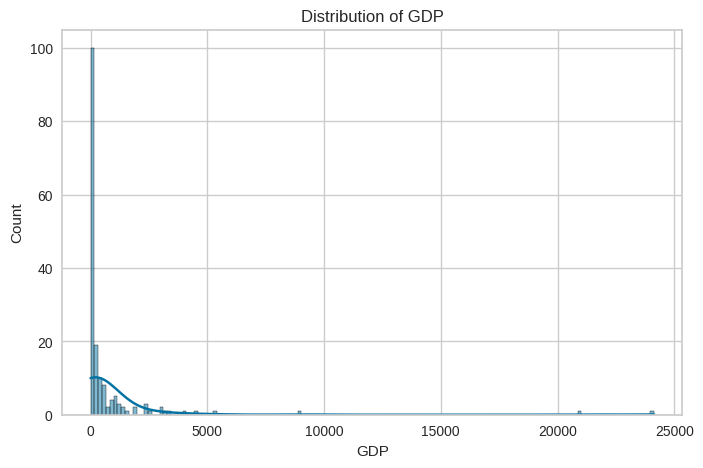

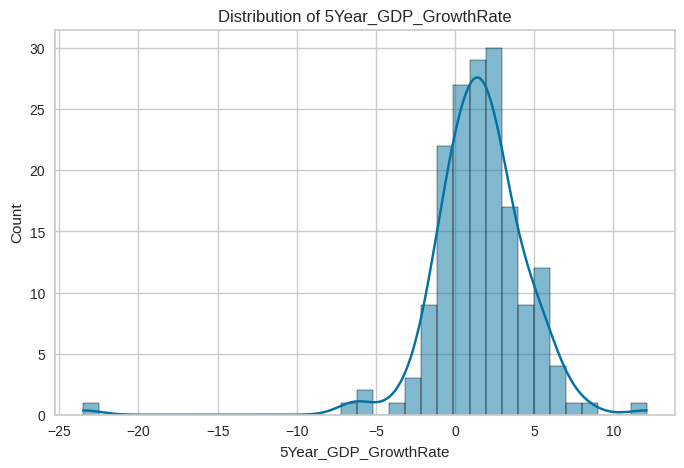

In [ ]:
for column in columns_to_check:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[column].dropna(), kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()

In [ ]:
from scipy.stats import skew, kurtosis

for column in columns_to_check:
    print(f"{column} skewness: {skew(df[column].dropna())}")
    print(f"{column} kurtosis: {kurtosis(df[column].dropna())}")

GDPperCapita skewness: 1.675185050208262
GDPperCapita kurtosis: 3.1930098433435345
PublicDebt skewness: 2.1711849237953667
PublicDebt kurtosis: 6.9000255412830285
Population skewness: 7.791937355795909
Population kurtosis: 64.17586990730905
GDP_GrowthRate skewness: 0.9963271340889108
GDP_GrowthRate kurtosis: 16.208009755161154
GDP skewness: 7.153797080044796
GDP kurtosis: 56.096668163625004
5Year_GDP_GrowthRate skewness: -2.6360886554095715
5Year_GDP_GrowthRate kurtosis: 21.001962392950123


Based on the distribution analysis of variables such as GDPperCapita and GDP, which show pronounced skewness and high kurtosis, DBSCAN algorithm will be used for clustering. This method is more robust to outliers and suitable for data with non-uniform density, which makes it more suitable for our task compared to K-Means.

### DBSCAN

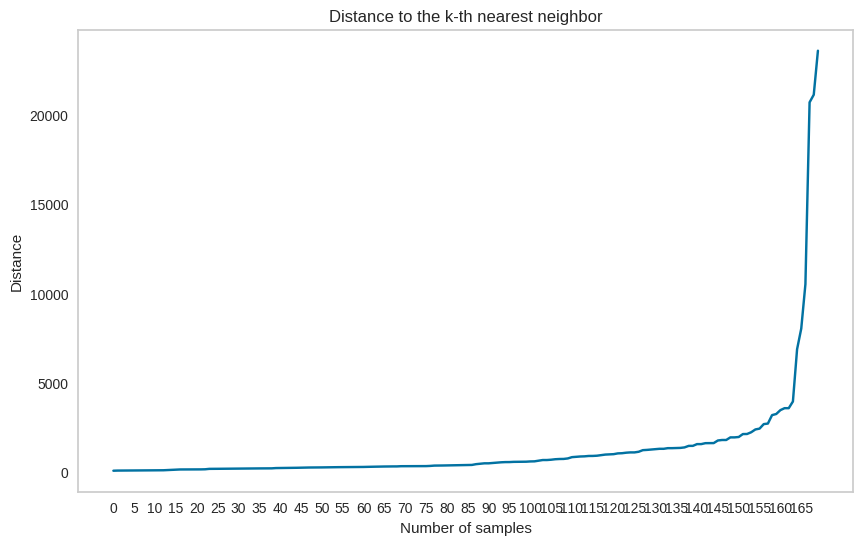

In [ ]:
from sklearn.neighbors import NearestNeighbors

data = df[columns_to_check].dropna()

min_samples = 3

# Calculate distance to the k-th nearest neighbor
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(data)
distances, indices = neighbors_fit.kneighbors(data)

# Sort Distance
distances = np.sort(distances[:, min_samples - 1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('Distance to the k-th nearest neighbor')
plt.xlabel('Number of samples')
plt.ylabel('Distance')
plt.xticks(np.arange(0, len(distances), 5))
plt.grid()
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

eps = 130

# DBSCAN use
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
clusters = dbscan.fit_predict(data)

df['DBSCAN_Cluster'] = clusters

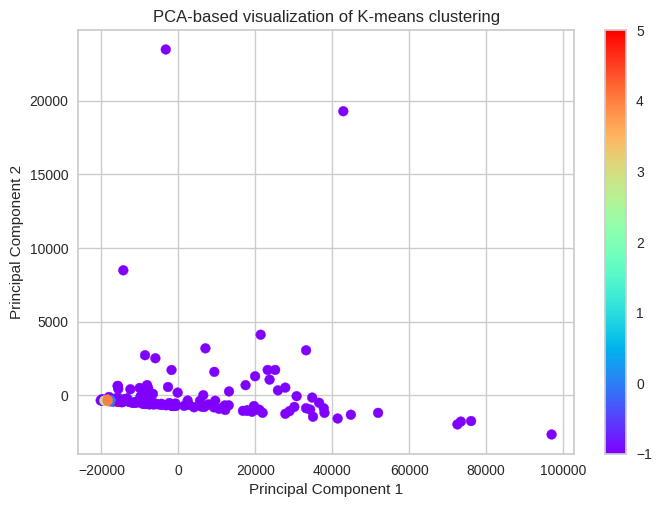

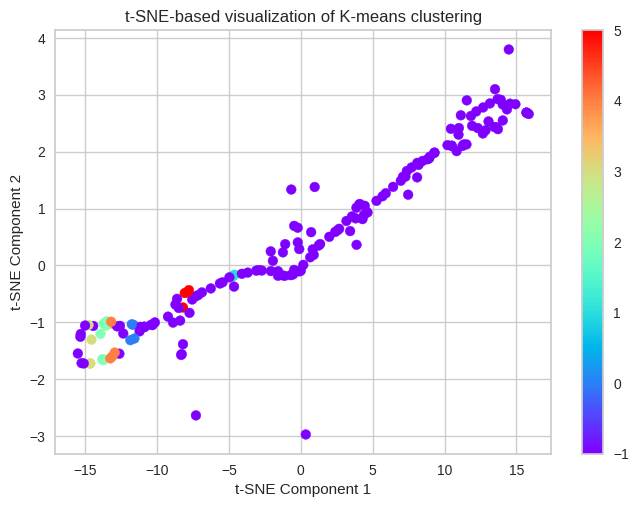

In [ ]:
#Visualisation
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
db_data_pca = pca.fit_transform(data)

plt.scatter(db_data_pca[:, 0], db_data_pca[:, 1], c=clusters, cmap='rainbow')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA-based visualization of K-means clustering')
plt.colorbar()
plt.show()

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
db_data_tsne = tsne.fit_transform(data)


plt.scatter(X_tsne[:, 0], db_data_tsne[:, 1], c=clusters, cmap='rainbow')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE-based visualization of K-means clustering')
plt.colorbar()
plt.show()

## Alternative option with K-Means

In [ ]:
data = df[columns_to_check].dropna()
data

,GDPperCapita,PublicDebt,Population,GDP_GrowthRate,GDP,5Year_GDP_GrowthRate
1,14218.0,76.0,2.8,-3.5,40.7,2.0
2,11112.0,53.1,43.9,-6.0,491.5,0.1
3,6932.0,127.1,32.9,-4.0,215.1,-1.9
4,20751.0,103.0,45.4,-10.0,941.8,-2.8
5,13261.0,62.8,3.0,-7.6,39.4,2.6
...,...,...,...,...,...,...
176,5178.0,304.1,28.4,-30.0,144.7,-23.5
177,10869.0,46.6,97.3,2.9,1058.7,6.1
179,3342.0,117.8,18.4,-3.5,63.1,1.9
180,2622.0,88.9,14.9,-8.0,39.8,-1.3


In [ ]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import calinski_harabasz_score

for k in range (2, 15):
    labels = KMeans(n_clusters=k).fit_predict(data)
    print('Number of clusters: {}, index {}'.format(k, calinski_harabasz_score(data, labels)))

Number of clusters: 2, index 385.9118015391221
Number of clusters: 3, index 401.2964203908638
Number of clusters: 4, index 545.565035260902
Number of clusters: 5, index 689.2268880729868
Number of clusters: 6, index 604.5127323869175
Number of clusters: 7, index 716.9456521200326
Number of clusters: 8, index 665.0769712828252
Number of clusters: 9, index 711.4126788462254
Number of clusters: 10, index 960.1603409948862
Number of clusters: 11, index 1088.4448383223253
Number of clusters: 12, index 1212.6791050277495
Number of clusters: 13, index 1429.6173245098323
Number of clusters: 14, index 1567.753160398861


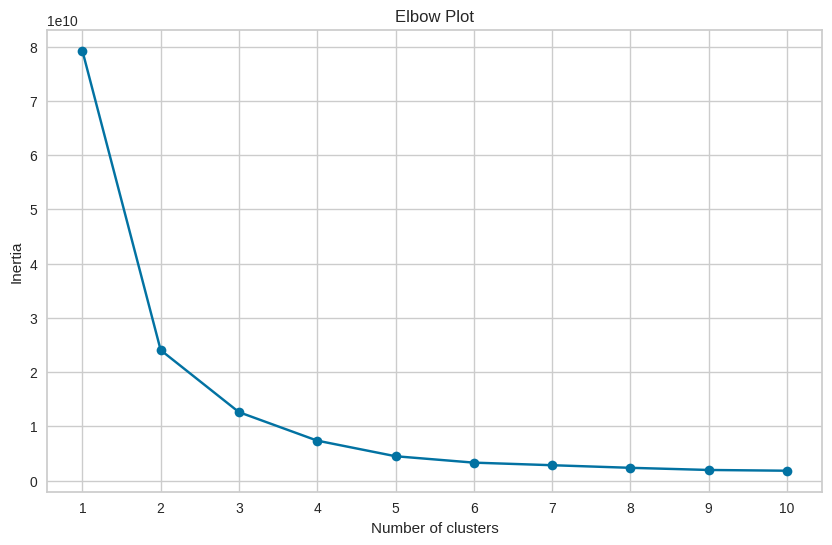

In [ ]:
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(data)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Plot')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.show()

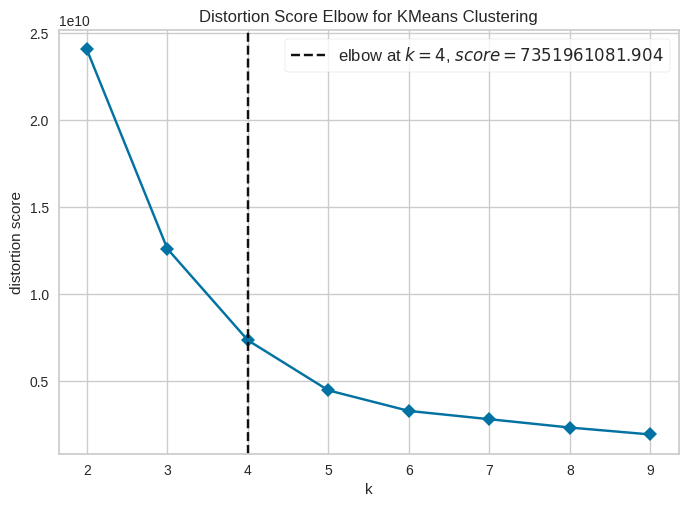

In [ ]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), timings=False)

visualizer.fit(data)
visualizer.show()
plt.show()

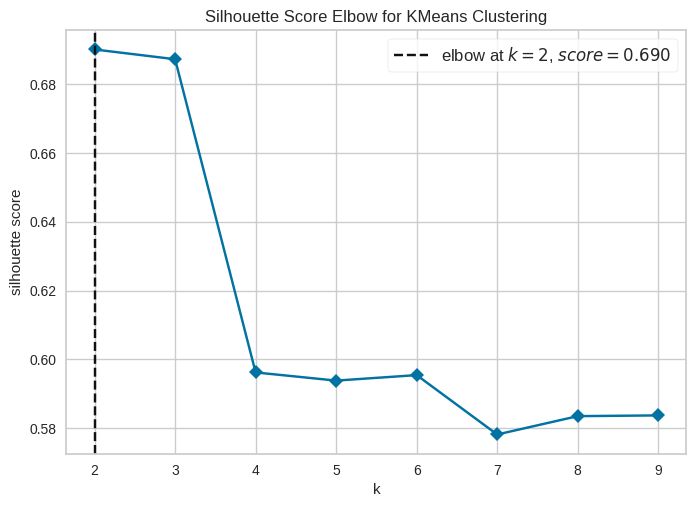

In [ ]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), metric='silhouette', timings=False)

visualizer.fit(data)
visualizer.show()
plt.show()

In [ ]:
# We will choose 4 clusters based on the different graphs above

kmeans_model = KMeans(n_clusters=4).fit_predict(data)

In [ ]:
df['KMeans_Clusters'] = kmeans_model
df.head()

,CountryID,CountryName,HighIncome,Income,Development,Region,WorldRank,RegionRank,2022Score,PropertyRights,...,GDP,GDP_GrowthRate,5Year_GDP_GrowthRate,GDPperCapita,Unemployment,Inflation,FDIInflow,PublicDebt,DBSCAN_Cluster,KMeans_Clusters
1,2,Albania,0,2,0,Europe,50.0,30.0,66.6,55.5,...,40.7,-3.5,2.0,14218.0,11.7,1.6,1107.0,76.0,-1,3
2,3,Algeria,0,2,0,Middle East and North Africa,167.0,13.0,45.8,27.9,...,491.5,-6.0,0.1,11112.0,12.8,2.4,1125.0,53.1,-1,3
3,4,Angola,0,2,0,Sub-Saharan Africa,139.0,29.0,52.6,39.8,...,215.1,-4.0,-1.9,6932.0,7.7,22.3,-1866.0,127.1,-1,3
4,5,Argentina,0,2,0,Americas,144.0,27.0,50.1,35.1,...,941.8,-10.0,-2.8,20751.0,11.7,42.0,4123.0,103.0,-1,1
5,6,Armenia,0,2,0,Europe,58.0,34.0,65.3,50.4,...,39.4,-7.6,2.6,13261.0,20.2,1.2,117.0,62.8,-1,3


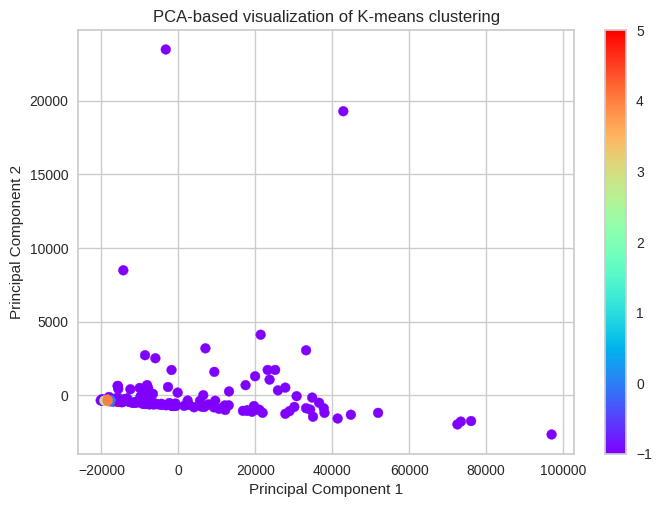

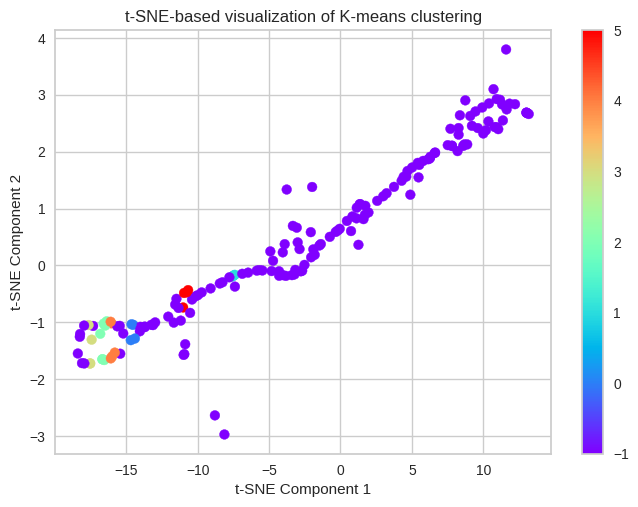

In [ ]:
#Visualisation
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
data_pca = pca.fit_transform(data)

plt.scatter(data_pca[:, 0], data_pca[:, 1], c=clusters, cmap='rainbow')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA-based visualization of K-means clustering')
plt.colorbar()
plt.show()

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
data_tsne = tsne.fit_transform(data)


plt.scatter(data_tsne[:, 0], data_tsne[:, 1], c=clusters, cmap='rainbow')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE-based visualization of K-means clustering')
plt.colorbar()
plt.show()

We've got very similar graphics

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


print(df)


pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

     CountryID                              CountryName  HighIncome  Income  \
1            2                                  Albania           0       2   
2            3                                  Algeria           0       2   
3            4                                   Angola           0       2   
4            5                                Argentina           0       2   
5            6                                  Armenia           0       2   
6            7                                Australia           1       3   
7            8                                  Austria           1       3   
8            9                               Azerbaijan           0       2   
9           10                                  Bahamas           1       3   
10          11                                  Bahrain           1       3   
11          12                               Bangladesh           0       2   
12          13                                 Barba

In [ ]:
grouped_kmeans = df.groupby('KMeans_Clusters').agg({
    'CountryName': 'count',
    'GDPperCapita': 'mean',
    'GDP': 'mean',
    'PublicDebt': 'mean',
    'Population': 'mean',
    'GDP_GrowthRate': 'mean',
    '5Year_GDP_GrowthRate': 'mean',
}).reset_index()

grouped_kmeans.rename(columns={
    'CountryName': 'Country Count',
    'KMeans_Clusters': 'Cluster ID'
}, inplace=True)

print(grouped_kmeans)

   Cluster ID  Country Count  GDPperCapita          GDP  PublicDebt  \
0           0              5  95166.600000   398.940000   65.680000   
1           1             36  24040.888889  1165.902778   66.844444   
2           2             32  48697.281250  1728.753125   75.637500   
3           3             97   6832.731959   320.722680   70.302062   

   Population  GDP_GrowthRate  5Year_GDP_GrowthRate  
0    4.560000       -1.960000              2.120000  
1   58.761111       -5.366667              1.219444  
2   33.393750       -4.521875              1.103125  
3   44.614433       -4.163918              1.712371  


In [ ]:
grouped_dbscan = df.groupby('DBSCAN_Cluster').agg({
    'CountryName': 'count',
    'GDPperCapita': 'mean',
    'GDP': 'mean',
    'PublicDebt': 'mean',
    'Population': 'mean',
    'GDP_GrowthRate': 'mean',
    '5Year_GDP_GrowthRate': 'mean',
}).reset_index()

grouped_dbscan.rename(columns={
    'CountryName': 'Country Count',
    'DBSCAN_Cluster': 'Cluster ID'
}, inplace=True)

print(grouped_dbscan)

   Cluster ID  Country Count  GDPperCapita         GDP  PublicDebt  \
0          -1            143  24236.216783  903.903497   73.378322   
1           0              4   3409.750000   41.900000   60.300000   
2           1              3   8353.000000  100.466667   62.400000   
3           2              7   2325.285714   21.957143   53.557143   
4           3              4   1623.000000   22.925000   55.075000   
5           4              5   2620.800000   37.740000   54.100000   
6           5              4   5510.750000   59.025000   46.825000   

   Population  GDP_GrowthRate  5Year_GDP_GrowthRate  
0   50.397203       -4.741958              1.328671  
1   12.125000       -1.875000              2.600000  
2   11.700000       -5.933333              1.300000  
3    9.657143       -1.057143              4.000000  
4   14.300000       -2.575000              1.075000  
5   15.220000       -3.720000              2.140000  
6   10.775000       -2.975000              2.150000  


### Clusters description

**KMeans Clustering**
- Emerging Economies: Low per capita income countries characterized by high population and moderate economic activity.
- High-Income Countries: Highly developed countries with high GDP per capita but low growth.
- Wealthy Countries: Economically strong countries with high GDP per capita, small populations and stable debt levels.
- Developing Countries: Middle-income countries that are still in the process of economic growth and have higher growth rates than the other clusters.

**DBSCAN Clustering:**
- Outlier Group: A group of countries with unique economic characteristics that differ from the rest of the clusters, possibly due to missing data or economic crises.
- Low-Income Countries: Countries with very low per capita income and small GDP, characterized by high aid dependence.
Lower-Middle Income Countries: Low-income countries that are beginning to show economic improvements but still face challenges.
- Lower-Income Countries: Countries with very low GDP and high debt burden that are vulnerable.
- Very Low-Income Countries: Countries with the lowest income levels and high dependence on foreign aid and subsidies.
- Transitioning Economies:Countries that are in transition from underdeveloped to more developed economies.
- Emerging Economies: Countries with growing economies that are showing improvement in their financial and social performance.

In [ ]:
kmeans_names = {
    0: "Emerging Economies",
    1: "High-Income Countries",
    2: "Wealthy Countries",
    3: "Developing Countries"
}

dbscan_names = {
    -1: "Outlier Group",
    0: "Low-Income Countries",
    1: "Lower-Middle Income Countries",
    2: "Lower-Income Countries",
    3: "Very Low-Income Countries",
    4: "Transitioning Economies",
    5: "Emerging Economies"
}

kmeans_results = grouped_kmeans.copy()
kmeans_results['Description'] = kmeans_results['Cluster ID'].map(kmeans_names)


dbscan_results = grouped_dbscan.copy()
dbscan_results['Description'] = dbscan_results['Cluster ID'].map(dbscan_names)


print("KMeans Clustering Results:")
kmeans_results[['Cluster ID', 'Country Count', 'GDPperCapita', 'GDP', 'PublicDebt', 'Description']]


KMeans Clustering Results:


,Cluster ID,Country Count,GDPperCapita,GDP,PublicDebt,Description
0,0,5,95166.600000,398.940000,65.680000,Emerging Economies
1,1,36,24040.888889,1165.902778,66.844444,High-Income Countries
2,2,32,48697.281250,1728.753125,75.637500,Wealthy Countries
3,3,97,6832.731959,320.722680,70.302062,Developing Countries


In [ ]:
print("\nDBSCAN Clustering Results:")
dbscan_results[['Cluster ID', 'Country Count', 'GDPperCapita', 'GDP', 'PublicDebt', 'Description']]


DBSCAN Clustering Results:


,Cluster ID,Country Count,GDPperCapita,GDP,PublicDebt,Description
0,-1,143,24236.216783,903.903497,73.378322,Outlier Group
1,0,4,3409.750000,41.900000,60.300000,Low-Income Countries
2,1,3,8353.000000,100.466667,62.400000,Lower-Middle Income Countries
3,2,7,2325.285714,21.957143,53.557143,Lower-Income Countries
4,3,4,1623.000000,22.925000,55.075000,Very Low-Income Countries
5,4,5,2620.800000,37.740000,54.100000,Transitioning Economies
6,5,4,5510.750000,59.025000,46.825000,Emerging Economies


## Task 2
- Do the descriptive analysis of all the variables which will be used in regression analysis.
Each quantitative output should be accompanied with your textual interpretation of the obtained statistics.
- Analyze all pairwise relationships between the variables which will be used in regression analysis based on the suitable statistical methods. Make conclusions about each obtained result. Make sure the selected predictors could be used simultaneously in one regression model.
- Do the linear regression analysis. Formulate all research hypotheses which will be verified during the regression analysis.
- Specify the regression equation. Assess the goodness-of-fit of the model.
- Describe the relationships between each predictor and dependent variable in detail.
Explain the meaning of each regression coefficient.
- Perform the model diagnostics.
- Make final conclusions about the results of analysis.

In [ ]:
df1 = original_df.copy()
df1 = df1.dropna()

# Fix data types
df1['GDPperCapita'] = df1['GDPperCapita'].replace({'\$': ''}, regex=True).str.replace(' ', '').str.replace(',', '.').astype(float)
df1['GDP'] = df1['GDP'].replace({'\$': ''}, regex=True).str.replace(' ', '').str.replace(',', '.').astype(float)
df1['2022Score'] = df1['2022Score'].str.replace(' ', '').str.replace(',', '.').astype(float)
df1['PropertyRights'] = df1['PropertyRights'].str.replace(' ', '').str.replace(',', '.').astype(float)
df1['Population'] = df1['Population'].str.replace(' ', '').str.replace(',', '.').astype(float)
df1['GDP_GrowthRate'] = df1['GDP_GrowthRate'].str.replace(' ', '').str.replace(',', '.').astype(float)
df1['5Year_GDP_GrowthRate'] = df1['5Year_GDP_GrowthRate'].str.replace(' ', '').str.replace(',', '.').astype(float)
df1['Unemployment'] = df1['Unemployment'].str.replace(' ', '').str.replace(',', '.').astype(float)
df1['Inflation'] = df1['Inflation'].str.replace(' ', '').str.replace(',', '.').astype(float)
df1['FDIInflow'] = df1['FDIInflow'].str.replace(' ', '').str.replace(',', '.').astype(float)
df1['PublicDebt'] = df1['PublicDebt'].str.replace(' ', '').str.replace(',', '.').astype(float)

df1

,CountryID,CountryName,HighIncome,Income,Development,Region,WorldRank,RegionRank,2022Score,PropertyRights,...,GovernmentExpenditurofGDP,Population,GDP,GDP_GrowthRate,5Year_GDP_GrowthRate,GDPperCapita,Unemployment,Inflation,FDIInflow,PublicDebt
1,2,Albania,0,middle income,developing,Europe,50.0,30.0,66.6,55.5,...,"30,5",2.8,40.7,-3.5,2.0,14218.0,11.7,1.6,1107.0,76.0
2,3,Algeria,0,middle income,developing,Middle East and North Africa,167.0,13.0,45.8,27.9,...,"37,8",43.9,491.5,-6.0,0.1,11112.0,12.8,2.4,1125.0,53.1
3,4,Angola,0,middle income,developing,Sub-Saharan Africa,139.0,29.0,52.6,39.8,...,"21,3",32.9,215.1,-4.0,-1.9,6932.0,7.7,22.3,-1866.0,127.1
4,5,Argentina,0,middle income,developing,Americas,144.0,27.0,50.1,35.1,...,"39,6",45.4,941.8,-10.0,-2.8,20751.0,11.7,42.0,4123.0,103.0
5,6,Armenia,0,middle income,developing,Europe,58.0,34.0,65.3,50.4,...,"26,5",3.0,39.4,-7.6,2.6,13261.0,20.2,1.2,117.0,62.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,179,Venezuela,0,middle income,developing,Americas,176.0,32.0,24.8,0.2,...,"26,9",28.4,144.7,-30.0,-23.5,5178.0,9.1,2355.1,959.0,304.1
177,180,Vietnam,0,middle income,developing,Asia-Pacific,84.0,18.0,60.6,49.6,...,"22,0",97.3,1058.7,2.9,6.1,10869.0,2.3,3.2,15800.0,46.6
179,182,Zambia,0,middle income,developing,Sub-Saharan Africa,154.0,36.0,48.7,38.3,...,"29,8",18.4,63.1,-3.5,1.9,3342.0,12.2,16.4,234.0,117.8
180,183,Zimbabwe,0,middle income,developing,Sub-Saharan Africa,173.0,46.0,33.1,20.8,...,"20,7",14.9,39.8,-8.0,-1.3,2622.0,5.7,557.2,194.0,88.9


### Correlation

In [ ]:
# # Removing some spikes/outliers from Yearly brutto salary (without bonus and stocks) in EUR column to lower their bad influence on our model and correlation

# def remove_outliers(df, column):
#     Q1 = df[column].quantile(0.25)
#     Q3 = df[column].quantile(0.75)
#     IQR = Q3 - Q1

#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR

#     return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# columns_to_check = df1.select_dtypes(include='number').columns.tolist()

# for column in columns_to_check:
#     df1 = remove_outliers(df1, column)

# print(df1.head())

In [ ]:
# Correlation with GDPperCapita
correlations1 = df1.corr(numeric_only=True)['GDPperCapita'].sort_values(ascending=False)

correlations1

,GDPperCapita
GDPperCapita,1.000000
HighIncome,0.812269
PropertyRights,0.747350
2022Score,0.716145
FinancialFreedom,0.639829
InvestmentFreedom,0.545289
FDIInflow,0.238033
GDP,0.164234
CountryID,0.072855
PublicDebt,0.017116


In [ ]:
columns_to_dummy = ['Income', 'Development', 'Region']

df_dummies = pd.get_dummies(df1, columns=columns_to_dummy, drop_first=False)
for column in df_dummies.columns:
    if df_dummies[column].dtype == 'bool':
        df_dummies[column] = df_dummies[column].astype(int)

df_dummies.head()

,CountryID,CountryName,HighIncome,WorldRank,RegionRank,2022Score,PropertyRights,JudicialEffectiveness,GovernmentIntegrity,TaxBurden,...,Income_high income,Income_low income,Income_middle income,Development_developed,Development_developing,Region_Americas,Region_Asia-Pacific,Region_Europe,Region_Middle East and North Africa,Region_Sub-Saharan Africa
1,2,Albania,0,50.0,30.0,66.6,55.5,"49,8","35,6","89,1",...,0,0,1,0,1,0,0,1,0,0
2,3,Algeria,0,167.0,13.0,45.8,27.9,"29,7","30,1","67,2",...,0,0,1,0,1,0,0,0,1,0
3,4,Angola,0,139.0,29.0,52.6,39.8,"25,3","20,6","86,6",...,0,0,1,0,1,0,0,0,0,1
4,5,Argentina,0,144.0,27.0,50.1,35.1,"57,9","45,1","73,3",...,0,0,1,0,1,1,0,0,0,0
5,6,Armenia,0,58.0,34.0,65.3,50.4,"33,1","50,8","86,9",...,0,0,1,0,1,0,0,1,0,0


In [ ]:
task2numericcols = ['GDPperCapita', 'HighIncome', 'PropertyRights', '2022Score', 'FinancialFreedom', 'WorldRank']
task2columns = ['GDPperCapita', 'HighIncome', 'PropertyRights', '2022Score', 'FinancialFreedom', 'WorldRank', 'Region_Americas', 'Region_Asia-Pacific', 'Region_Middle East and North Africa', 'Region_Sub-Saharan Africa', 'Development_developing', 'Income_low income', 'Income_middle income']
df_dummies = df_dummies[task2columns]
df_dummies
# Region_Europe, Development_developed and Income_high will be reference categories as the most developed ones


,GDPperCapita,HighIncome,PropertyRights,2022Score,FinancialFreedom,WorldRank,Region_Americas,Region_Asia-Pacific,Region_Middle East and North Africa,Region_Sub-Saharan Africa,Development_developing,Income_low income,Income_middle income
1,14218.0,0,55.5,66.6,70.0,50.0,0,0,0,0,1,0,1
2,11112.0,0,27.9,45.8,30.0,167.0,0,0,1,0,1,0,1
3,6932.0,0,39.8,52.6,40.0,139.0,0,0,0,1,1,0,1
4,20751.0,0,35.1,50.1,60.0,144.0,1,0,0,0,1,0,1
5,13261.0,0,50.4,65.3,70.0,58.0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,5178.0,0,0.2,24.8,10.0,176.0,1,0,0,0,1,0,1
177,10869.0,0,49.6,60.6,50.0,84.0,0,1,0,0,1,0,1
179,3342.0,0,38.3,48.7,50.0,154.0,0,0,0,1,1,0,1
180,2622.0,0,20.8,33.1,10.0,173.0,0,0,0,1,1,0,1


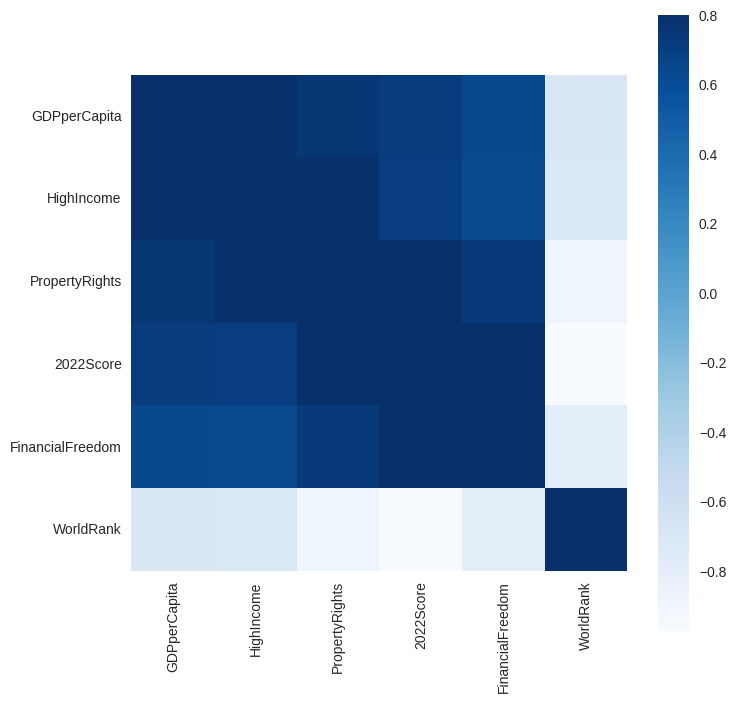

In [ ]:
# Correlation graph for all numeric columns

corr = df_dummies[task2numericcols].corr(numeric_only=True)
plt.figure(figsize=(8, 8))
sns.heatmap(corr, vmax=.8, square=True, cmap='Blues')
plt.show()

In [ ]:
df1.corrwith(df_dummies['GDPperCapita'], numeric_only=True).sort_values(ascending=False)

,0
GDPperCapita,1.000000
HighIncome,0.812269
PropertyRights,0.747350
2022Score,0.716145
FinancialFreedom,0.639829
InvestmentFreedom,0.545289
FDIInflow,0.238033
GDP,0.164234
CountryID,0.072855
PublicDebt,0.017116


In [ ]:
df_dummies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 170 entries, 1 to 183
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   GDPperCapita                         170 non-null    float64
 1   HighIncome                           170 non-null    int64  
 2   PropertyRights                       170 non-null    float64
 3   2022Score                            170 non-null    float64
 4   FinancialFreedom                     170 non-null    float64
 5   WorldRank                            170 non-null    float64
 6   Region_Americas                      170 non-null    int64  
 7   Region_Asia-Pacific                  170 non-null    int64  
 8   Region_Middle East and North Africa  170 non-null    int64  
 9   Region_Sub-Saharan Africa            170 non-null    int64  
 10  Development_developing               170 non-null    int64  
 11  Income_low income                    

In [ ]:
df_dummies.describe()

,GDPperCapita,HighIncome,PropertyRights,2022Score,FinancialFreedom,WorldRank,Region_Americas,Region_Asia-Pacific,Region_Middle East and North Africa,Region_Sub-Saharan Africa,Development_developing,Income_low income,Income_middle income
count,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000
mean,20955.252941,0.311765,55.404118,60.538235,49.705882,87.841176,0.176471,0.211765,0.082353,0.270588,0.776471,0.135294,0.552941
std,21496.450462,0.464583,24.050616,10.735894,18.021239,51.326586,0.382346,0.409766,0.275714,0.445576,0.417841,0.343048,0.498658
min,760.000000,0.000000,0.200000,24.800000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5157.000000,0.000000,37.575000,53.300000,40.000000,43.250000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,13091.500000,0.000000,50.350000,59.900000,50.000000,88.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
75%,31263.250000,1.000000,74.725000,67.925000,60.000000,132.750000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000
max,118002.000000,1.000000,100.000000,84.400000,90.000000,176.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


The dataset reveals significant economic diversity among the 170 countries, with a majority classified as developing and a smaller percentage as high-income. Key indicators such as GDP per capita, property rights, and financial freedom exhibit substantial variability, suggesting considerable opportunities for improvement in economic stability and governance across different regions.

In [ ]:
for column in df1.columns:
  count_of_1 = (df1[column] == 1).sum()
  print(f"Column '{column}': Count of 1 = {count_of_1}")

Column 'CountryID': Count of 1 = 0
Column 'CountryName': Count of 1 = 0
Column 'HighIncome': Count of 1 = 53
Column 'Income': Count of 1 = 0
Column 'Development': Count of 1 = 0
Column 'Region': Count of 1 = 0
Column 'WorldRank': Count of 1 = 1
Column 'RegionRank': Count of 1 = 5
Column '2022Score': Count of 1 = 0
Column 'PropertyRights': Count of 1 = 0
Column 'JudicialEffectiveness': Count of 1 = 0
Column 'GovernmentIntegrity': Count of 1 = 0
Column 'TaxBurden': Count of 1 = 0
Column 'GovernmentSpending': Count of 1 = 0
Column 'FiscalHealth': Count of 1 = 0
Column 'BusinessFreedom': Count of 1 = 0
Column 'LaborFreedom': Count of 1 = 0
Column 'MonetaryFreedom': Count of 1 = 0
Column 'TradeFreedom': Count of 1 = 0
Column 'InvestmentFreedom': Count of 1 = 0
Column 'FinancialFreedom': Count of 1 = 0
Column 'TariffRate': Count of 1 = 0
Column 'IncomeTaxRate': Count of 1 = 0
Column 'CorporateTaxRate': Count of 1 = 0
Column 'TaxBurdenofGDP': Count of 1 = 0
Column 'GovernmentExpenditurofGDP '

In [ ]:
df_dummies['HighIncome'].value_counts()

,count
HighIncome,
0,117
1,53


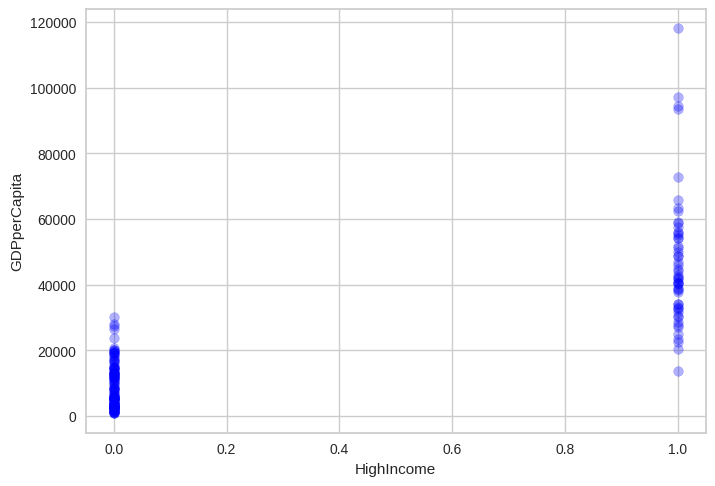

In [ ]:
plt.scatter(df_dummies['HighIncome'], df_dummies['GDPperCapita'], c = 'blue', marker = 'o', alpha=0.3)
plt.xlabel('HighIncome')
plt.ylabel('GDPperCapita')
plt.show()

In [ ]:
df_dummies['FinancialFreedom'].value_counts()

,count
FinancialFreedom,
50.0,38
60.0,31
40.0,26
30.0,23
70.0,22
80.0,12
20.0,12
10.0,4
90.0,2


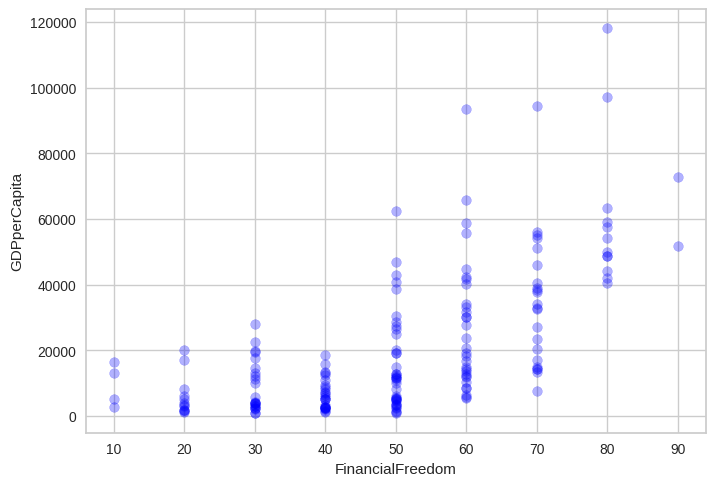

In [ ]:
plt.scatter(df_dummies['FinancialFreedom'], df_dummies['GDPperCapita'], c = 'blue', marker = 'o', alpha=0.3)
plt.xlabel('FinancialFreedom')
plt.ylabel('GDPperCapita')
plt.show()

In [ ]:
df_dummies['PropertyRights'].value_counts()

,count
PropertyRights,
58.8,3
36.8,2
83.2,2
85.6,2
43.2,2
...,...
26.8,1
47.6,1
60.7,1


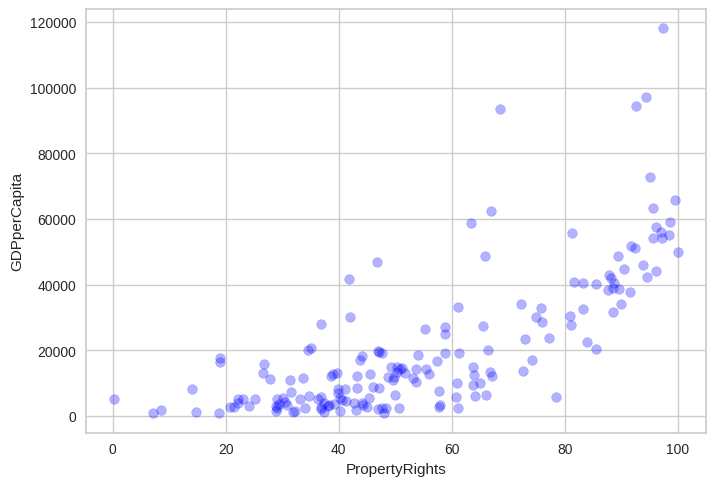

In [ ]:
plt.scatter(df_dummies['PropertyRights'], df_dummies['GDPperCapita'], c = 'blue', marker = 'o', alpha=0.3)
plt.xlabel('PropertyRights')
plt.ylabel('GDPperCapita')
plt.show()

In [ ]:
df_dummies['2022Score'].value_counts()

,count
2022Score,
54.2,3
65.4,3
59.5,3
63.2,2
58.3,2
...,...
80.0,1
39.7,1
47.2,1


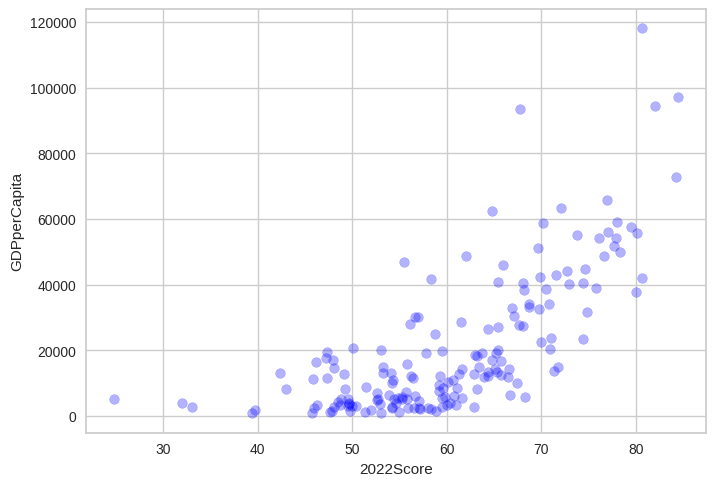

In [ ]:
plt.scatter(df_dummies['2022Score'], df_dummies['GDPperCapita'], c = 'blue', marker = 'o', alpha=0.3)
plt.xlabel('2022Score')
plt.ylabel('GDPperCapita')
plt.show()

In [ ]:
df_dummies['WorldRank'].value_counts()

,count
WorldRank,
50.0,1
123.0,1
4.0,1
122.0,1
121.0,1
...,...
16.0,1
89.0,1
77.0,1


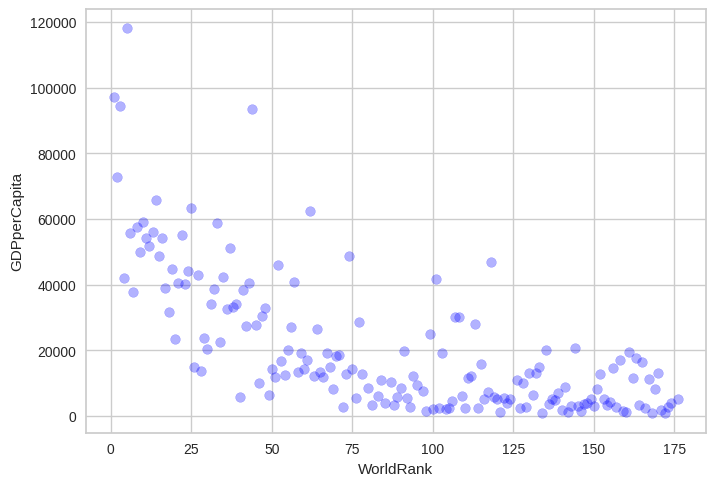

In [ ]:
plt.scatter(df_dummies['WorldRank'], df_dummies['GDPperCapita'], c = 'blue', marker = 'o', alpha=0.3)
plt.xlabel('WorldRank')
plt.ylabel('GDPperCapita')
plt.show()

For linear categories we can see some positive/negative relation, mostly not very strong

## Multiple linear regression

In [ ]:
df_model = df_dummies.dropna(subset=task2columns)

df_model.shape

(170, 13)

In [ ]:
import statsmodels.api as sm

x_mult = df_model[task2columns]

y = df_model['GDPperCapita']
x_mult_constant = sm.add_constant(x_mult)

In [ ]:
model = sm.OLS(y, x_mult_constant).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           GDPperCapita   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.147e+31
Date:                Sat, 19 Oct 2024   Prob (F-statistic):               0.00
Time:                        13:26:46   Log-Likelihood:                 3923.8
No. Observations:                 170   AIC:                            -7822.
Df Residuals:                     157   BIC:                            -7781.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

In [ ]:
print('Adjusted R^2 = {:f}'.format(model.rsquared_adj))
print('F-test significance = {:f}'.format(model.f_pvalue))

Adjusted R^2 = 1.000000
F-test significance = 0.000000


In [ ]:
from sklearn.metrics import mean_absolute_error

true_values = df_model['GDPperCapita']
predicted_values = model.fittedvalues
mae = mean_absolute_error(true_values, predicted_values)
print('Mean Absolute Error:', mae)

Mean Absolute Error: 2.1675398730782463e-11


In [ ]:
from sklearn.metrics import mean_squared_error

true_values = df_model['GDPperCapita']
predicted_values =  model.fittedvalues

mse = mean_squared_error(true_values, predicted_values)
print('Mean Squared Error:', mse)

Mean Squared Error: 5.23945931527706e-22


In [ ]:
true_values = df_model['GDPperCapita']
predicted_values =  model.fittedvalues
rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
print('Root Mean Squared Error (RMSE):', rmse)

Root Mean Squared Error (RMSE): 2.2889865257963096e-11


In [ ]:
f'Statistically significant model parameters: {model.pvalues[model.pvalues < 0.05].index.values}'

"Statistically significant model parameters: ['GDPperCapita']"

In [ ]:
f'Statistically insignificant model parameters: {model.pvalues[model.pvalues > 0.05].index.values}'

"Statistically insignificant model parameters: ['const' 'HighIncome' 'PropertyRights' '2022Score' 'FinancialFreedom'\n 'WorldRank' 'Region_Americas' 'Region_Asia-Pacific'\n 'Region_Middle East and North Africa' 'Region_Sub-Saharan Africa'\n 'Development_developing' 'Income_low income' 'Income_middle income']"

In [ ]:
l = []
for (param, index) in zip(model.params[1:], model.params.index[1:]):
    l.append('{:.2f}*{}'.format(param, index))

print('Y = {:2f} + {}'.format(model.params[0], ' + '.join(l)))

Y = 0.000000 + 1.00*GDPperCapita + 0.00*HighIncome + -0.00*PropertyRights + 0.00*2022Score + -0.00*FinancialFreedom + 0.00*WorldRank + 0.00*Region_Americas + 0.00*Region_Asia-Pacific + 0.00*Region_Middle East and North Africa + 0.00*Region_Sub-Saharan Africa + -0.00*Development_developing + 0.00*Income_low income + 0.00*Income_middle income


## Task 3
Nowadays, there is high demand for qualified data analysts, and the number of
educational programs in this sphere is constantly growing. These programs are implemented at different educational levels and in various formats. <br>
Let’s concentrate our attention on the Master’s Degree Programs in Data Science. What quantitative indicators can be used to assess the effectiveness of the implementation of master's degree programs in Data Science in Russian
universities? <br>
Propose a methodology of a quantitative research based on which will be possible to identify factors influencing the effectiveness of the implementation of master's degree programs in Data Science in Russian universities. <br>Formulate research questions and hypotheses.<br>
How the research sample could be formed? <br>What kind of variables could be used in the analysis (list possible variables)? <br>
What methods of quantitative data analysis could be applied?